# Phase 2: Unsupervised Learning for Initial Detection (Anomaly-Based IDS)
# Task 2.1: Packet-Level Anomaly Detection
# Autoencoder

Build an unsupervised model that separates benign from non-benign packets.

## Setup, load metadata and sampled packet dataset

In [1]:
import json
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans

METADATA_FILE_NAME = "packet_sample_seed1.metadata.json"
PROJECT_ROOT = Path("..")
META_PATH = PROJECT_ROOT / "data" / "samples" / METADATA_FILE_NAME

with open(META_PATH, "r") as f:
    metadata = json.load(f)

DATA_PATH = PROJECT_ROOT / metadata["output_path"]
df = pd.read_csv(DATA_PATH)

BINARY_COL = "binary_label"
ATTACK_COL = "attack_type"
y_true = df[BINARY_COL].map({"benign": 0, "attack": 1}).to_numpy()

print("Dataset shape:", df.shape)
print("\nBinary class counts:")
print(df[BINARY_COL].value_counts())
print("\nTraffic type counts:")
print(df[ATTACK_COL].value_counts())

Dataset shape: (205041, 138)

Binary class counts:
binary_label
benign    200000
attack      5041
Name: count, dtype: int64

Traffic type counts:
attack_type
Benign             200000
DNS Spoofing         3178
DDoS-HTTP Flood       833
Brute Force           404
DoS-HTTP Flood        364
XSS                   262
Name: count, dtype: int64


## Data preprocessing

### Autoencoder feature selection

The autoencoder uses numeric packet behavior, protocol, timing, size, and short-term traffic statistics. Raw IP addresses, MAC addresses, host names, URIs, and user-agent strings are excluded because they are identifiers rather than stable behavior features. A small set of 1, 5, and 30-window statistics is kept, then highly correlated columns are removed using the training set only.

In [2]:
# Basic packet behavior features
base_features = [
    "time_since_previously_displayed_frame",
    "port_class_dst",
    "l4_tcp",
    "l4_udp",
    "ttl",
    "eth_size",
    "tcp_window_size",
    "payload_entropy",
    "payload_length",
    "jitter",
    "dns_len_qry",
    "dns_interval",
    "dns_len_ans",
    "http_content_len",
    "http_response_code",
    "handshake_cipher_suites_length",
    "handshake_extensions_length",
    "handshake_sig_hash_alg_len",
    "icmp_data_size",
    "l3_ip_dst_count",
    "average_p",
    "var_p",
    "iqr_p"
]

# Keep useful short-term and longer-term traffic statistics
rolling_features = []

for group in ["stream", "src_ip", "channel"]:
    rolling_features += [f"{group}_{window}_count" for window in [1, 5, 30]]
    rolling_features += [f"{group}_{window}_{stat}" for window in [5, 30] for stat in ["mean", "var"]]

rolling_features += [
    "stream_jitter_5_mean",
    "stream_jitter_5_var",
    "stream_jitter_30_mean",
    "stream_jitter_30_var"
]

requested_features = base_features + rolling_features
missing_features = [col for col in requested_features if col not in df.columns]
feature_cols = [col for col in requested_features if col in df.columns]
X_raw = df[feature_cols].apply(pd.to_numeric, errors="coerce").copy()

print("Initial selected features:", X_raw.shape[1])
print("Missing requested features:", missing_features)

Initial selected features: 48
Missing requested features: []


### Autoencoder feature engineering

The added features describe protocol usage, payload presence, port behavior, and sudden traffic bursts. These are more useful than raw port numbers and help the autoencoder learn normal packet relationships without using labels.

In [3]:
src_port = pd.to_numeric(df["src_port"], errors="coerce").fillna(-1)
dst_port = pd.to_numeric(df["dst_port"], errors="coerce").fillna(-1)
packet_size = pd.to_numeric(df["eth_size"], errors="coerce").replace(0, np.nan)
payload_size = pd.to_numeric(df["payload_length"], errors="coerce").fillna(0)
dns_query = pd.to_numeric(df["dns_len_qry"], errors="coerce").fillna(0)
dns_answer = pd.to_numeric(df["dns_len_ans"], errors="coerce").fillna(0)
dns_type = pd.to_numeric(df["dns_query_type"], errors="coerce").fillna(-1)
http_length = pd.to_numeric(df["http_content_len"], errors="coerce").fillna(0)
http_code = pd.to_numeric(df["http_response_code"], errors="coerce").fillna(0)
tls_length = pd.to_numeric(df["handshake_extensions_length"], errors="coerce").fillna(0)
icmp_size = pd.to_numeric(df["icmp_data_size"], errors="coerce").fillna(-1)

highest_layer = df["highest_layer"].fillna("none").astype(str).str.upper()
http_method = df["http_request_method"].fillna("none").astype(str).str.upper()
http_uri = df["http_uri"].fillna("").astype(str).replace("none", "")
http_host = df["http_host"].fillna("").astype(str).replace("none", "")
user_agent = df["user_agent"].fillna("").astype(str).replace("none", "")
dns_name = df["dns_server"].fillna("").astype(str).replace("none", "")

X_raw["payload_ratio"] = (payload_size / packet_size).clip(0, 1).fillna(0)
X_raw["has_payload"] = (payload_size > 0).astype(int)
X_raw["uses_dns_port"] = ((src_port == 53) | (dst_port == 53)).astype(int)
X_raw["has_dns_data"] = ((dns_query > 0) | (dns_answer > 0)).astype(int)
X_raw["dns_total_length"] = dns_query + dns_answer
X_raw["dns_answer_ratio"] = (dns_answer / (dns_query + 1)).clip(0, 20)
X_raw["dns_name_length"] = dns_name.str.len()
X_raw["dns_label_count"] = dns_name.str.count(r"\.")
X_raw["dns_type_a"] = (dns_type == 1).astype(int)
X_raw["dns_type_ptr"] = (dns_type == 12).astype(int)
X_raw["dns_type_aaaa"] = (dns_type == 28).astype(int)

X_raw["uses_http_port"] = ((src_port == 80) | (dst_port == 80)).astype(int)
X_raw["uses_https_port"] = ((src_port == 443) | (dst_port == 443)).astype(int)
X_raw["has_http_data"] = ((http_length > 0) | (http_code > 0)).astype(int)
X_raw["has_http_uri"] = (http_uri.str.len() > 0).astype(int)
X_raw["http_uri_length"] = http_uri.str.len()
X_raw["http_uri_special_ratio"] = (http_uri.str.count(r"[^A-Za-z0-9]") / http_uri.str.len().replace(0, np.nan)).fillna(0)
X_raw["http_uri_digit_ratio"] = (http_uri.str.count(r"\d") / http_uri.str.len().replace(0, np.nan)).fillna(0)
X_raw["http_query_parts"] = http_uri.str.count(r"[?&=]")
X_raw["http_host_length"] = http_host.str.len()
X_raw["user_agent_length"] = user_agent.str.len()
X_raw["http_method_get"] = (http_method == "GET").astype(int)
X_raw["http_method_post"] = (http_method == "POST").astype(int)
X_raw["http_status_2xx"] = http_code.between(200, 299).astype(int)
X_raw["http_status_4xx"] = http_code.between(400, 499).astype(int)
X_raw["http_status_5xx"] = http_code.between(500, 599).astype(int)

X_raw["has_tls_handshake"] = (tls_length > 0).astype(int)
X_raw["is_icmp"] = (icmp_size >= 0).astype(int)
X_raw["src_port_ephemeral"] = (src_port >= 49152).astype(int)
X_raw["dst_port_ephemeral"] = (dst_port >= 49152).astype(int)
X_raw["same_src_dst_port"] = (src_port == dst_port).astype(int)

service_ports = {
    "ssh": [22],
    "telnet": [23],
    "ntp": [123],
    "mqtt": [1883, 8883],
    "rtsp": [554],
    "ssdp": [1900]
}

for service, ports in service_ports.items():
    X_raw[f"uses_{service}_port"] = (src_port.isin(ports) | dst_port.isin(ports)).astype(int)

for layer in ["DNS", "HTTP", "TLS", "SSH", "ICMP", "ARP"]:
    X_raw[f"layer_{layer.lower()}"] = (highest_layer == layer).astype(int)

def burst_ratio(short_col, long_col):
    short_count = pd.to_numeric(df[short_col], errors="coerce").fillna(0)
    long_count = pd.to_numeric(df[long_col], errors="coerce").fillna(0)
    recent_rate = short_count / 5
    previous_rate = (long_count - short_count).clip(lower=0) / 25
    return (recent_rate + 1) / (previous_rate + 1)

for group in ["stream", "src_ip", "channel"]:
    X_raw[f"{group}_burst_ratio"] = burst_ratio(f"{group}_5_count", f"{group}_30_count")

print("Features after engineering:", X_raw.shape[1])
X_raw.head()


Features after engineering: 94


,time_since_previously_displayed_frame,port_class_dst,l4_tcp,l4_udp,ttl,eth_size,tcp_window_size,payload_entropy,payload_length,jitter,...,uses_ssdp_port,layer_dns,layer_http,layer_tls,layer_ssh,layer_icmp,layer_arp,stream_burst_ratio,src_ip_burst_ratio,channel_burst_ratio
0,0.000185,1,1,0,64,60,0,0.000000,0,0.000185,...,0,0,0,0,0,0,0,3.800000,1.179039,3.800000
1,0.000290,3,1,0,49,66,65024,0.000000,0,0.000290,...,0,0,0,0,0,0,0,2.800000,1.085714,1.051051
2,0.003855,1,1,0,64,74,14600,0.000000,0,947.623914,...,0,0,0,0,0,0,0,1.200000,1.081081,1.072508
3,0.003104,3,0,1,64,60,0,3.201876,16,0.005255,...,0,0,0,0,0,0,0,2.777778,1.371681,2.826087
4,0.000001,3,1,0,231,66,4415,0.000000,0,0.000001,...,0,0,0,0,0,0,0,1.429706,1.451327,1.429140


### Basic preprocessing

The data is divided into 60% training, 20% validation, and 20% test sets using the same split style as the K-means and Isolation Forest notebooks. Preprocessing is learned from the training set only. Missing rolling variance or jitter values are set to zero because they usually mean that too few earlier packets were available. Other missing values are median-imputed, skewed non-negative features are log-transformed, highly correlated features are removed, and the remaining inputs are standardized for neural-network training. Standardized values are clipped to the range -10 to 10 so a few extreme packets do not dominate the reconstruction loss.

Labels are stored only for validation and final evaluation. They are not passed to the autoencoder or its optimizer during fitting.

In [4]:
# Create 60% training, 20% validation and 20% test sets
all_idx = np.arange(len(df))
train_idx, temp_idx = train_test_split(all_idx, test_size=0.40, random_state=1, stratify=df[ATTACK_COL])
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=1, stratify=df.iloc[temp_idx][ATTACK_COL])

# Clean values before learning preprocessing information
X_clean = X_raw.replace([np.inf, -np.inf], np.nan).copy()
zero_fill_cols = [col for col in X_clean.columns if col.endswith("_var") or "jitter" in col]
X_clean[zero_fill_cols] = X_clean[zero_fill_cols].fillna(0)

X_train_df = X_clean.iloc[train_idx].copy()
X_val_df = X_clean.iloc[val_idx].copy()
X_test_df = X_clean.iloc[test_idx].copy()

# Remove unusable columns using training data only
drop_cols = [col for col in X_train_df.columns if X_train_df[col].isna().all() or X_train_df[col].nunique(dropna=True) <= 1]
X_train_df = X_train_df.drop(columns=drop_cols)
X_val_df = X_val_df.drop(columns=drop_cols)
X_test_df = X_test_df.drop(columns=drop_cols)

# Reduce extreme skew without changing binary indicators
log_cols = []
for col in X_train_df.columns:
    values = X_train_df[col].dropna()
    if len(values) > 0 and values.min() >= 0 and values.nunique() > 2 and abs(values.skew()) > 2:
        log_cols.append(col)

for split in [X_train_df, X_val_df, X_test_df]:
    split[log_cols] = np.log1p(split[log_cols].clip(lower=0))

# Remove nearly duplicate features using training correlations only
CORRELATED_FEATURE_THRESHOLD = 0.98
correlation = X_train_df.corr(numeric_only=True).abs()
upper_triangle = correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
correlated_cols = [col for col in upper_triangle.columns if (upper_triangle[col] > CORRELATED_FEATURE_THRESHOLD).any()]

X_train_df = X_train_df.drop(columns=correlated_cols)
X_val_df = X_val_df.drop(columns=correlated_cols)
X_test_df = X_test_df.drop(columns=correlated_cols)

preprocess = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

X_train = preprocess.fit_transform(X_train_df).astype(np.float32)
X_val = preprocess.transform(X_val_df).astype(np.float32)
X_test = preprocess.transform(X_test_df).astype(np.float32)

X_train = np.clip(X_train, -10, 10)
X_val = np.clip(X_val, -10, 10)
X_test = np.clip(X_test, -10, 10)
processed_feature_names = preprocess.named_steps["imputer"].get_feature_names_out(X_train_df.columns)

y_train = y_true[train_idx]
y_val = y_true[val_idx]
y_test = y_true[test_idx]

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)
print("\nPreprocessing summary:")
print("Removed unusable features:", len(drop_cols))
print("Removed correlated features:", len(correlated_cols))
print("Log-transformed features:", len(log_cols))
print("Final model inputs:", len(processed_feature_names))
print("All values finite:", np.isfinite(X_train).all() and np.isfinite(X_val).all() and np.isfinite(X_test).all())
print("\nAttack counts:")
print("Train:", y_train.sum())
print("Validation:", y_val.sum())
print("Test:", y_test.sum())

Training shape: (123024, 84)
Validation shape: (41008, 84)
Test shape: (41009, 84)

Preprocessing summary:
Removed unusable features: 3
Removed correlated features: 12
Log-transformed features: 54
Final model inputs: 84
All values finite: True

Attack counts:
Train: 3024
Validation: 1008
Test: 1009


## Autoencoder model

The model is a small denoising autoencoder. During training, Gaussian noise is added to each input batch, while the clean batch remains the reconstruction target. This discourages the network from learning a simple identity mapping. The encoder compresses the packet features into a low-dimensional bottleneck and the decoder reconstructs the original standardized features.

Packet labels are not used by the model, loss function, optimizer, or early-stopping rule.

In [5]:
torch.set_num_threads(min(4, os.cpu_count() or 1))

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

RANDOM_STATE = 1
BATCH_SIZE = 1024 if len(X_train) >= 1024 else 128


def set_seed(seed=RANDOM_STATE):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


class PacketAutoencoder(nn.Module):
    def __init__(self, input_dim, bottleneck_dim=8, dropout=0.10):
        super().__init__()
        if not 1 <= bottleneck_dim < 32:
            raise ValueError("bottleneck_dim must be between 1 and 31")
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 64), nn.ReLU(), nn.Linear(64, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


print("Device:", DEVICE)
print("Input features:", X_train.shape[1])
print("Training batch size:", BATCH_SIZE)

Device: mps
Input features: 84
Training batch size: 1024


### Training and reconstruction-error functions

The autoencoder is trained with Smooth L1 loss, which is less sensitive to a small number of extreme packets than ordinary mean squared error. Gaussian noise and random feature masking make the model learn stable packet structure instead of copying every input value. Early stopping uses validation reconstruction loss only and does not use validation labels.

Packet anomaly scoring still begins with squared feature-level reconstruction errors. Later sections calibrate and combine these residuals so naturally difficult features do not dominate the final score.


In [6]:
def make_loader(X, batch_size, shuffle=False):
    data = TensorDataset(torch.from_numpy(X))
    return DataLoader(data, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=DEVICE.type == "cuda")


def train_autoencoder(X_train, X_val, bottleneck_dim, dropout=0.10, noise_std=0.05, mask_rate=0.05, learning_rate=1e-3, weight_decay=1e-5, max_epochs=25, patience=4):
    set_seed()
    model = PacketAutoencoder(X_train.shape[1], bottleneck_dim, dropout).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = nn.SmoothL1Loss(beta=0.5)
    train_loader = make_loader(X_train, BATCH_SIZE, shuffle=True)
    val_loader = make_loader(X_val, BATCH_SIZE)
    history, best_loss, best_state, wait = [], np.inf, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss = 0.0

        for (batch,) in train_loader:
            batch = batch.to(DEVICE)
            noisy_batch = batch + noise_std * torch.randn_like(batch)
            noisy_batch = noisy_batch.masked_fill(torch.rand_like(batch) < mask_rate, 0)
            optimizer.zero_grad()
            loss = criterion(model(noisy_batch), batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(batch)

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(DEVICE)
                val_loss += criterion(model(batch), batch).item() * len(batch)

        train_loss /= len(X_train)
        val_loss /= len(X_val)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_loss - 1e-5:
            best_loss = val_loss
            best_state = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

            if wait >= patience:
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


@torch.no_grad()
def reconstruction_feature_errors(model, X, batch_size=4096):
    model.eval()
    errors = []

    for (batch,) in make_loader(X, batch_size):
        batch = batch.to(DEVICE)
        errors.append(((model(batch) - batch) ** 2).cpu().numpy())

    return np.concatenate(errors)


@torch.no_grad()
def encode_packets(model, X, batch_size=4096):
    model.eval()
    embeddings = []

    for (batch,) in make_loader(X, batch_size):
        embeddings.append(model.encoder(batch.to(DEVICE)).cpu().numpy())

    return np.concatenate(embeddings)


def aggregate_errors(feature_errors, top_k=None):
    if top_k is None:
        return feature_errors.mean(axis=1)

    k = min(top_k, feature_errors.shape[1])
    return np.partition(feature_errors, -k, axis=1)[:, -k:].mean(axis=1)


def fit_error_calibrator(train_feature_errors):
    center = np.median(train_feature_errors, axis=0)
    q25, q75, q90 = np.quantile(train_feature_errors, [0.25, 0.75, 0.90], axis=0)
    scale = q75 - q25
    fallback = q90 - center
    scale = np.where(scale > 1e-8, scale, fallback)
    scale = np.where(scale > 1e-8, scale, 1.0)
    return center, scale


def calibrate_errors(feature_errors, center, scale):
    calibrated = np.maximum((feature_errors - center) / scale, 0)
    return np.log1p(calibrated)


def percentile_scores(reference_scores, scores):
    reference_scores = np.sort(np.asarray(reference_scores))
    return np.searchsorted(reference_scores, scores, side="right") / len(reference_scores)


def reconstruction_errors(model, X, top_k=None, batch_size=4096):
    return aggregate_errors(reconstruction_feature_errors(model, X, batch_size), top_k)


## Tuning

### Tune the bottleneck size and anomaly-score aggregation

The encoder first reduces the input to 32 hidden values, so a valid bottleneck must be smaller than 32. Larger values would expand the 32-value hidden layer rather than compress it.

For each valid bottleneck, the model is trained without labels. The validation labels are used only afterward to compare several reconstruction-error summaries. Mean error measures the full packet, while top-k error focuses on the few features reconstructed most poorly. Validation PR-AUC is the main selection metric because attacks are rare.

In [7]:
bottleneck_values = [4, 6, 8, 10, 12, 14, 16, 20, 24, 28]
score_options = {"Mean": None, "Top 10": 10, "Top 5": 5, "Top 3": 3, "Maximum": 1}
tuning_rows = []

for bottleneck_dim in bottleneck_values:
    start_time = time.time()
    model, history = train_autoencoder(X_train, X_val, bottleneck_dim, max_epochs=20)
    score_rows = []

    for score_name, top_k in score_options.items():
        candidate_scores = reconstruction_errors(model, X_val, top_k=top_k)
        score_rows.append({
            "score_mode": score_name,
            "top_k": np.nan if top_k is None else top_k,
            "val_pr_auc": average_precision_score(y_val, candidate_scores),
            "val_roc_auc": roc_auc_score(y_val, candidate_scores)
        })

    best_score = pd.DataFrame(score_rows).sort_values(["val_pr_auc", "val_roc_auc"], ascending=False).iloc[0]
    tuning_rows.append({
        "bottleneck_dim": bottleneck_dim,
        "score_mode": best_score["score_mode"],
        "top_k": best_score["top_k"],
        "epochs": len(history),
        "val_loss": history["val_loss"].min(),
        "val_pr_auc": best_score["val_pr_auc"],
        "val_roc_auc": best_score["val_roc_auc"],
        "train_time_sec": time.time() - start_time
    })
    print(f"Bottleneck {bottleneck_dim}: PR-AUC={best_score['val_pr_auc']:.4f}, score={best_score['score_mode']}")

autoencoder_tuning_df = pd.DataFrame(tuning_rows).sort_values(["val_pr_auc", "val_roc_auc"], ascending=False).reset_index(drop=True)
tuning_display = autoencoder_tuning_df.copy()
tuning_display["top_k"] = tuning_display["top_k"].apply(lambda value: "All features" if pd.isna(value) else int(value))
display(tuning_display.round(4))

Bottleneck 4: PR-AUC=0.0796, score=Mean
Bottleneck 6: PR-AUC=0.0727, score=Mean
Bottleneck 8: PR-AUC=0.0782, score=Mean
Bottleneck 10: PR-AUC=0.0861, score=Mean
Bottleneck 12: PR-AUC=0.0728, score=Mean
Bottleneck 14: PR-AUC=0.0731, score=Mean
Bottleneck 16: PR-AUC=0.0723, score=Mean
Bottleneck 20: PR-AUC=0.0706, score=Mean
Bottleneck 24: PR-AUC=0.0783, score=Mean
Bottleneck 28: PR-AUC=0.0685, score=Mean


,bottleneck_dim,score_mode,top_k,epochs,val_loss,val_pr_auc,val_roc_auc,train_time_sec
0,10,Mean,All features,20,0.0607,0.0861,0.8146,14.2404
1,4,Mean,All features,20,0.0737,0.0796,0.8114,16.1641
2,24,Mean,All features,20,0.0562,0.0783,0.8103,14.2135
3,8,Mean,All features,20,0.0609,0.0782,0.8177,14.1802
4,14,Mean,All features,20,0.0564,0.0731,0.8107,14.1661
5,12,Mean,All features,20,0.0585,0.0728,0.8141,14.2373
6,6,Mean,All features,20,0.0660,0.0727,0.8152,14.2261
7,16,Mean,All features,20,0.0567,0.0723,0.8046,14.3511
8,20,Mean,All features,20,0.0561,0.0706,0.7979,14.2160
9,28,Mean,All features,20,0.0543,0.0685,0.8109,14.2820


### Select the best configuration

The selected configuration has the highest validation PR-AUC. This selects both the latent bottleneck and the way feature-level reconstruction errors are combined into one packet anomaly score. The test set is not used during selection.

In [8]:
best_row = autoencoder_tuning_df.iloc[0]
BEST_BOTTLENECK = int(best_row["bottleneck_dim"])
BEST_SCORE_MODE = best_row["score_mode"]
BEST_TOP_K = None if pd.isna(best_row["top_k"]) else int(best_row["top_k"])

print("Selected bottleneck size:", BEST_BOTTLENECK)
print("Selected score mode:", BEST_SCORE_MODE)
print("Validation PR-AUC:", round(best_row["val_pr_auc"], 4))
print("Validation ROC-AUC:", round(best_row["val_roc_auc"], 4))

Selected bottleneck size: 10
Selected score mode: Mean
Validation PR-AUC: 0.0861
Validation ROC-AUC: 0.8146


## Training model

### Train the final denoising autoencoder

The final model is retrained from the same training split using the selected bottleneck. Validation reconstruction loss controls early stopping. Labels remain excluded from training.

Training epochs: 30
Best validation loss: 0.056615
Training time (seconds): 20.5


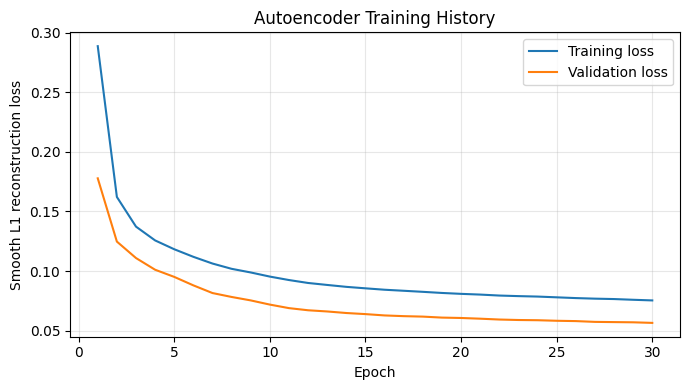

In [9]:
start_train = time.time()
base_autoencoder, training_history = train_autoencoder(X_train, X_val, BEST_BOTTLENECK, max_epochs=30, patience=5)
base_train_time = time.time() - start_train

print("Training epochs:", len(training_history))
print("Best validation loss:", round(training_history["val_loss"].min(), 6))
print("Training time (seconds):", round(base_train_time, 2))

plt.figure(figsize=(7, 4))
plt.plot(training_history["epoch"], training_history["train_loss"], label="Training loss")
plt.plot(training_history["epoch"], training_history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Smooth L1 reconstruction loss")
plt.title("Autoencoder Training History")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Robust unsupervised refinement

The first autoencoder is trained on the complete training split. Because the training sample contains a small unknown amount of anomalous traffic, packets with the largest initial reconstruction errors can influence the learned normal pattern.

To reduce this contamination without using packet labels, the notebook removes only the highest-scoring 5% of training packets and trains a second autoencoder on the remaining 95%. The validation set is still kept separate and is not used to decide which training packets are removed.


In [10]:
TRIM_RATE = 0.05
initial_train_scores = reconstruction_errors(base_autoencoder, X_train)
initial_val_scores = reconstruction_errors(base_autoencoder, X_val)
train_trim_threshold = np.quantile(initial_train_scores, 1 - TRIM_RATE)
val_trim_threshold = np.quantile(initial_val_scores, 1 - TRIM_RATE)

refined_mask = initial_train_scores < train_trim_threshold
refined_val_mask = initial_val_scores < val_trim_threshold
X_train_refined = X_train[refined_mask]
X_val_refined = X_val[refined_val_mask]

start_refine = time.time()
refined_autoencoder, refined_history = train_autoencoder(X_train_refined, X_val_refined, BEST_BOTTLENECK, max_epochs=30, patience=5)
refined_train_time = time.time() - start_refine

print("Training packets kept:", f"{len(X_train_refined):,}", f"({refined_mask.mean() * 100:.1f}%)")
print("Validation packets used for early stopping:", f"{len(X_val_refined):,}", f"({refined_val_mask.mean() * 100:.1f}%)")
print("Training packets trimmed:", f"{(~refined_mask).sum():,}")
print("Refined training epochs:", len(refined_history))
print("Best refined validation loss:", round(refined_history["val_loss"].min(), 6))
print("Refined training time (seconds):", round(refined_train_time, 2))


Training packets kept: 116,872 (95.0%)
Validation packets used for early stopping: 38,957 (95.0%)
Training packets trimmed: 6,152
Refined training epochs: 30
Best refined validation loss: 0.050498
Refined training time (seconds): 18.77


### Calibrate feature-level reconstruction errors

A raw mean reconstruction score can be dominated by features that are naturally difficult to reconstruct. The following step learns the normal residual size of each feature from the training set, scales each residual relative to that baseline, and then compares several aggregation rules.

This calibration uses only training reconstruction errors. Validation labels are used afterward only to select the model variant and score aggregation with the best PR-AUC.


In [11]:
score_options = {
    "Raw mean": ("raw", None),
    "Calibrated mean": ("calibrated", None),
    "Calibrated top 20": ("calibrated", 20),
    "Calibrated top 10": ("calibrated", 10),
    "Calibrated top 5": ("calibrated", 5),
    "Calibrated top 3": ("calibrated", 3)
}

candidate_models = {
    "Base": (base_autoencoder, X_train),
    "Refined": (refined_autoencoder, X_train_refined)
}

score_rows = []
score_cache = {}

for model_name, (model, calibration_X) in candidate_models.items():
    calibration_feature_errors = reconstruction_feature_errors(model, calibration_X)
    train_feature_errors = reconstruction_feature_errors(model, X_train)
    val_feature_errors = reconstruction_feature_errors(model, X_val)
    center, scale = fit_error_calibrator(calibration_feature_errors)
    calibrated_val_errors = calibrate_errors(val_feature_errors, center, scale)

    score_cache[model_name] = {
        "model": model,
        "center": center,
        "scale": scale,
        "calibration_X": calibration_X,
        "calibration_feature_errors": calibration_feature_errors,
        "train_feature_errors": train_feature_errors,
        "val_feature_errors": val_feature_errors
    }

    for score_name, (score_type, top_k) in score_options.items():
        source_errors = val_feature_errors if score_type == "raw" else calibrated_val_errors
        candidate_scores = aggregate_errors(source_errors, top_k)

        score_rows.append({
            "model_variant": model_name,
            "score_mode": score_name,
            "top_k": np.nan if top_k is None else top_k,
            "val_pr_auc": average_precision_score(y_val, candidate_scores),
            "val_roc_auc": roc_auc_score(y_val, candidate_scores)
        })

score_tuning_df = pd.DataFrame(score_rows).sort_values(["val_pr_auc", "val_roc_auc"], ascending=False).reset_index(drop=True)
score_display = score_tuning_df.copy()
score_display["top_k"] = score_display["top_k"].apply(lambda value: "All features" if pd.isna(value) else int(value))
display(score_display.round(4))

best_score_row = score_tuning_df.iloc[0]
BEST_MODEL_VARIANT = best_score_row["model_variant"]
BEST_SCORE_MODE = best_score_row["score_mode"]
BEST_TOP_K = None if pd.isna(best_score_row["top_k"]) else int(best_score_row["top_k"])
BEST_SCORE_TYPE = score_options[BEST_SCORE_MODE][0]

autoencoder = score_cache[BEST_MODEL_VARIANT]["model"]
error_center = score_cache[BEST_MODEL_VARIANT]["center"]
error_scale = score_cache[BEST_MODEL_VARIANT]["scale"]

print("Selected model variant:", BEST_MODEL_VARIANT)
print("Selected score mode:", BEST_SCORE_MODE)
print("Validation PR-AUC:", round(best_score_row["val_pr_auc"], 4))
print("Validation ROC-AUC:", round(best_score_row["val_roc_auc"], 4))


,model_variant,score_mode,top_k,val_pr_auc,val_roc_auc
0,Base,Calibrated mean,All features,0.2420,0.8306
1,Base,Calibrated top 20,20,0.2000,0.8261
2,Refined,Calibrated mean,All features,0.1676,0.8205
3,Base,Calibrated top 10,10,0.1311,0.8079
4,Refined,Calibrated top 20,20,0.1019,0.8109
5,Base,Calibrated top 5,5,0.0914,0.7745
6,Base,Raw mean,All features,0.0853,0.8179
7,Refined,Calibrated top 10,10,0.0761,0.7976
8,Refined,Raw mean,All features,0.0756,0.8224
9,Base,Calibrated top 3,3,0.0708,0.7420


Selected model variant: Base
Selected score mode: Calibrated mean
Validation PR-AUC: 0.242
Validation ROC-AUC: 0.8306


### Tune a hybrid reconstruction and latent-cluster score

Reconstruction error can miss packets that are reconstructed well but occupy an unusual location in the learned latent space. Mini-batch K-means is therefore fitted to the selected autoencoder's training embeddings. Labels are not used to fit the clusters. Validation PR-AUC selects the cluster count and the weight assigned to reconstruction error. A reconstruction-only option is included so the hybrid score is kept only when it improves validation performance.


In [12]:
start_score = time.time()
selected_cache = score_cache[BEST_MODEL_VARIANT]
calibration_feature_errors = selected_cache["calibration_feature_errors"]
train_feature_errors = selected_cache["train_feature_errors"]
val_feature_errors = selected_cache["val_feature_errors"]
test_feature_errors = reconstruction_feature_errors(autoencoder, X_test)

if BEST_SCORE_TYPE == "calibrated":
    calibration_score_errors = calibrate_errors(calibration_feature_errors, error_center, error_scale)
    train_score_errors = calibrate_errors(train_feature_errors, error_center, error_scale)
    val_score_errors = calibrate_errors(val_feature_errors, error_center, error_scale)
    test_score_errors = calibrate_errors(test_feature_errors, error_center, error_scale)
else:
    calibration_score_errors = calibration_feature_errors
    train_score_errors = train_feature_errors
    val_score_errors = val_feature_errors
    test_score_errors = test_feature_errors

calibration_reconstruction_scores = aggregate_errors(calibration_score_errors, BEST_TOP_K)
train_reconstruction_scores = aggregate_errors(train_score_errors, BEST_TOP_K)
val_reconstruction_scores = aggregate_errors(val_score_errors, BEST_TOP_K)
test_reconstruction_scores = aggregate_errors(test_score_errors, BEST_TOP_K)

train_reconstruction_percentile = percentile_scores(calibration_reconstruction_scores, train_reconstruction_scores)
val_reconstruction_percentile = percentile_scores(calibration_reconstruction_scores, val_reconstruction_scores)
test_reconstruction_percentile = percentile_scores(calibration_reconstruction_scores, test_reconstruction_scores)

latent_fit_X = X_train_refined if BEST_MODEL_VARIANT == "Refined" else X_train
latent_fit = encode_packets(autoencoder, latent_fit_X)
train_latent = encode_packets(autoencoder, X_train)
val_latent = encode_packets(autoencoder, X_val)
test_latent = encode_packets(autoencoder, X_test)

hybrid_rows = [{
    "clusters": 0,
    "reconstruction_weight": 1.0,
    "val_pr_auc": average_precision_score(y_val, val_reconstruction_percentile),
    "val_roc_auc": roc_auc_score(y_val, val_reconstruction_percentile)
}]
cluster_cache = {}

for n_clusters in [10, 25, 50]:
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, batch_size=4096, n_init=5, random_state=1)
    kmeans.fit(latent_fit)

    fit_distance = kmeans.transform(latent_fit).min(axis=1)
    train_distance = kmeans.transform(train_latent).min(axis=1)
    val_distance = kmeans.transform(val_latent).min(axis=1)
    test_distance = kmeans.transform(test_latent).min(axis=1)

    train_latent_percentile = percentile_scores(fit_distance, train_distance)
    val_latent_percentile = percentile_scores(fit_distance, val_distance)
    test_latent_percentile = percentile_scores(fit_distance, test_distance)

    cluster_cache[n_clusters] = {
        "model": kmeans,
        "train_scores": train_latent_percentile,
        "val_scores": val_latent_percentile,
        "test_scores": test_latent_percentile
    }

    for reconstruction_weight in [0.75, 0.50, 0.25, 0.0]:
        candidate_scores = reconstruction_weight * val_reconstruction_percentile + (1 - reconstruction_weight) * val_latent_percentile
        hybrid_rows.append({
            "clusters": n_clusters,
            "reconstruction_weight": reconstruction_weight,
            "val_pr_auc": average_precision_score(y_val, candidate_scores),
            "val_roc_auc": roc_auc_score(y_val, candidate_scores)
        })

hybrid_tuning_df = pd.DataFrame(hybrid_rows).sort_values(["val_pr_auc", "val_roc_auc"], ascending=False).reset_index(drop=True)
display(hybrid_tuning_df.round(4))

best_hybrid_row = hybrid_tuning_df.iloc[0]
BEST_CLUSTER_K = int(best_hybrid_row["clusters"])
BEST_RECONSTRUCTION_WEIGHT = float(best_hybrid_row["reconstruction_weight"])

if BEST_CLUSTER_K == 0:
    train_scores = train_reconstruction_percentile
    val_scores = val_reconstruction_percentile
    test_scores = test_reconstruction_percentile
    FINAL_SCORE_MODE = BEST_SCORE_MODE
else:
    selected_cluster_scores = cluster_cache[BEST_CLUSTER_K]
    train_scores = BEST_RECONSTRUCTION_WEIGHT * train_reconstruction_percentile + (1 - BEST_RECONSTRUCTION_WEIGHT) * selected_cluster_scores["train_scores"]
    val_scores = BEST_RECONSTRUCTION_WEIGHT * val_reconstruction_percentile + (1 - BEST_RECONSTRUCTION_WEIGHT) * selected_cluster_scores["val_scores"]
    test_scores = BEST_RECONSTRUCTION_WEIGHT * test_reconstruction_percentile + (1 - BEST_RECONSTRUCTION_WEIGHT) * selected_cluster_scores["test_scores"]
    FINAL_SCORE_MODE = f"{BEST_SCORE_MODE} + latent K-means"

score_time = time.time() - start_score
train_time = base_train_time + refined_train_time

score_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "mean_score": [train_scores.mean(), val_scores.mean(), test_scores.mean()],
    "median_score": [np.median(train_scores), np.median(val_scores), np.median(test_scores)],
    "max_score": [train_scores.max(), val_scores.max(), test_scores.max()]
})

print("Model variant:", BEST_MODEL_VARIANT)
print("Final score mode:", FINAL_SCORE_MODE)
print("Latent clusters:", "Not used" if BEST_CLUSTER_K == 0 else BEST_CLUSTER_K)
print("Reconstruction weight:", round(BEST_RECONSTRUCTION_WEIGHT, 2))
print("Scoring and latent tuning time (seconds):", round(score_time, 2))
display(score_summary.round(6))


,clusters,reconstruction_weight,val_pr_auc,val_roc_auc
0,25,0.75,0.2977,0.8283
1,25,0.50,0.2953,0.8125
2,25,0.25,0.2932,0.7837
3,10,0.75,0.2745,0.8274
4,10,0.50,0.2585,0.8035
5,25,0.00,0.2524,0.7498
6,0,1.00,0.2420,0.8306
7,10,0.25,0.2366,0.7586
8,50,0.75,0.2294,0.8368
9,50,0.50,0.2161,0.8336


Model variant: Base
Final score mode: Calibrated mean + latent K-means
Latent clusters: 25
Reconstruction weight: 0.75
Scoring and latent tuning time (seconds): 2.18


,split,mean_score,median_score,max_score
0,Train,0.500004,0.498771,0.999876
1,Validation,0.501154,0.500180,0.999750
2,Test,0.500040,0.497752,0.999880


## Threshold selection and evaluation

The reconstruction error is a continuous anomaly score. A packet becomes an alert only when its score is greater than or equal to the selected threshold. The threshold is selected using validation data and then applied unchanged to the test set.

### Select alert threshold using the validation set

Several validation alert rates are tested. Among thresholds with a false-positive rate no greater than 1.5%, the threshold with the highest validation F1-score is selected. Labels are used here only to evaluate threshold choices after unsupervised training.

In [13]:
alert_rates = np.arange(0.005, 0.051, 0.001)
threshold_rows = []

for alert_rate in alert_rates:
    threshold = np.quantile(val_scores, 1 - alert_rate)
    val_pred = (val_scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, val_pred, labels=[0, 1]).ravel()

    threshold_rows.append({
        "alert_rate": alert_rate,
        "threshold": threshold,
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp),
        "tp": tp,
        "fp": fp,
        "fn": fn
    })

threshold_df = pd.DataFrame(threshold_rows)
MAX_VAL_FPR = 0.015
valid_thresholds = threshold_df[threshold_df["fpr"] <= MAX_VAL_FPR]

if len(valid_thresholds) == 0:
    valid_thresholds = threshold_df.copy()

best_threshold_row = valid_thresholds.sort_values(["f1", "recall"], ascending=False).iloc[0]
FINAL_THRESHOLD = best_threshold_row["threshold"]

shown_rows = pd.concat([threshold_df.iloc[::5], best_threshold_row.to_frame().T])
shown_rows = shown_rows.drop_duplicates("alert_rate").sort_values("alert_rate")
display(shown_rows.round(4))

print("Selected alert rate:", round(best_threshold_row["alert_rate"], 3))
print("Selected threshold:", round(FINAL_THRESHOLD, 6))
print("Validation precision:", round(best_threshold_row["precision"], 4))
print("Validation recall:", round(best_threshold_row["recall"], 4))
print("Validation F1:", round(best_threshold_row["f1"], 4))
print("Validation FPR:", round(best_threshold_row["fpr"], 4))


,alert_rate,threshold,precision,recall,f1,fpr,fnr,tp,fp,fn
0,0.005,0.9918,0.7621,0.1558,0.2586,0.0012,0.8442,157.0,49.0,851.0
5,0.010,0.9802,0.6423,0.2619,0.3721,0.0037,0.7381,264.0,147.0,744.0
6,0.011,0.9776,0.6040,0.2708,0.3740,0.0045,0.7292,273.0,179.0,735.0
10,0.015,0.9678,0.4805,0.2937,0.3645,0.0080,0.7063,296.0,320.0,712.0
15,0.020,0.9582,0.3922,0.3194,0.3521,0.0125,0.6806,322.0,499.0,686.0
20,0.025,0.9509,0.3333,0.3393,0.3363,0.0171,0.6607,342.0,684.0,666.0
25,0.030,0.9428,0.2965,0.3621,0.3260,0.0216,0.6379,365.0,866.0,643.0
30,0.035,0.9344,0.2681,0.3819,0.3151,0.0263,0.6181,385.0,1051.0,623.0
35,0.040,0.9273,0.2480,0.4038,0.3073,0.0308,0.5962,407.0,1234.0,601.0
40,0.045,0.9208,0.2291,0.4196,0.2964,0.0356,0.5804,423.0,1423.0,585.0


Selected alert rate: 0.011
Selected threshold: 0.977558
Validation precision: 0.604
Validation recall: 0.2708
Validation F1: 0.374
Validation FPR: 0.0045


### Apply the frozen threshold

The selected validation threshold is applied directly to both validation and test reconstruction errors. It is not recalculated using the test labels or test score distribution.

In [14]:
val_pred = (val_scores >= FINAL_THRESHOLD).astype(int)
test_pred = (test_scores >= FINAL_THRESHOLD).astype(int)

df_val_result = df.iloc[val_idx].copy()
df_val_result["model"] = "Autoencoder"
df_val_result["anomaly_score"] = val_scores
df_val_result["y_pred"] = val_pred

df_test_result = df.iloc[test_idx].copy()
df_test_result["model"] = "Autoencoder"
df_test_result["anomaly_score"] = test_scores
df_test_result["y_pred"] = test_pred

print("Validation alerts:", val_pred.sum())
print("Test alerts:", test_pred.sum())

Validation alerts: 452
Test alerts: 428


## Evaluation

### Phase 2 evaluation metrics

The following table reports the required packet-level metrics: accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC, false-positive rate, false-negative rate, confusion-matrix counts, alert count, and runtime.

In [15]:
def evaluate_phase2(y_true, y_pred, scores, model_name, runtime_sec):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores),
        "fpr": fp / (fp + tn),
        "fnr": fn / (fn + tp),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "alerts": y_pred.sum(),
        "runtime_sec": runtime_sec
    }

    return pd.DataFrame([result])


metrics_df = evaluate_phase2(y_test, test_pred, test_scores, "Autoencoder", train_time + score_time)
display(metrics_df.round(4))

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,fpr,fnr,tp,fp,tn,fn,alerts,runtime_sec
0,Autoencoder,0.977,0.5748,0.2438,0.3424,0.8269,0.274,0.0046,0.7562,246,182,39818,763,428,41.4424


### Validation and test comparison

In [16]:
val_metrics_df = evaluate_phase2(y_val, val_pred, val_scores, "Validation", train_time + score_time)
test_metrics_df = evaluate_phase2(y_test, test_pred, test_scores, "Test", train_time + score_time)

comparison_df = pd.concat([val_metrics_df, test_metrics_df], ignore_index=True)
display(comparison_df[["model", "precision", "recall", "f1", "roc_auc", "pr_auc", "fpr", "fnr", "alerts"]].round(4))

,model,precision,recall,f1,roc_auc,pr_auc,fpr,fnr,alerts
0,Validation,0.6040,0.2708,0.3740,0.8283,0.2977,0.0045,0.7292,452
1,Test,0.5748,0.2438,0.3424,0.8269,0.2740,0.0046,0.7562,428


### Threshold sensitivity analysis

The plot shows how precision, recall, F1-score, and false-positive rate change as the validation alert rate increases. The dashed line marks the selected alert rate.

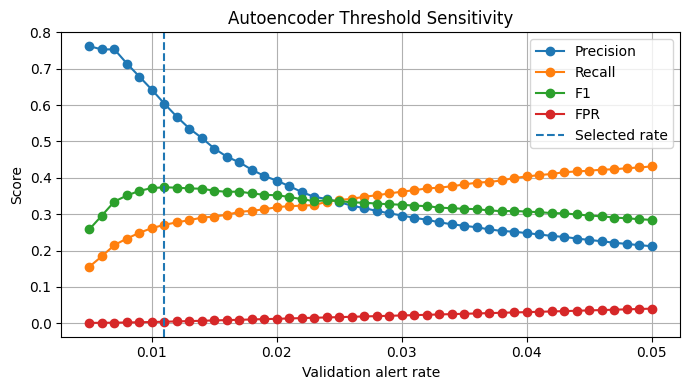

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(threshold_df["alert_rate"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["alert_rate"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["alert_rate"], threshold_df["f1"], marker="o", label="F1")
plt.plot(threshold_df["alert_rate"], threshold_df["fpr"], marker="o", label="FPR")
plt.axvline(best_threshold_row["alert_rate"], linestyle="--", label="Selected rate")
plt.xlabel("Validation alert rate")
plt.ylabel("Score")
plt.title("Autoencoder Threshold Sensitivity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Results by traffic type

Classification results by traffic type:


,total,correct,incorrect,correct_rate
attack_type,,,,
Benign,40000,39818,182,99.54
DDoS-HTTP Flood,167,139,28,83.23
DoS-HTTP Flood,73,66,7,90.41
DNS Spoofing,636,37,599,5.82
Brute Force,81,4,77,4.94
XSS,52,0,52,0.00


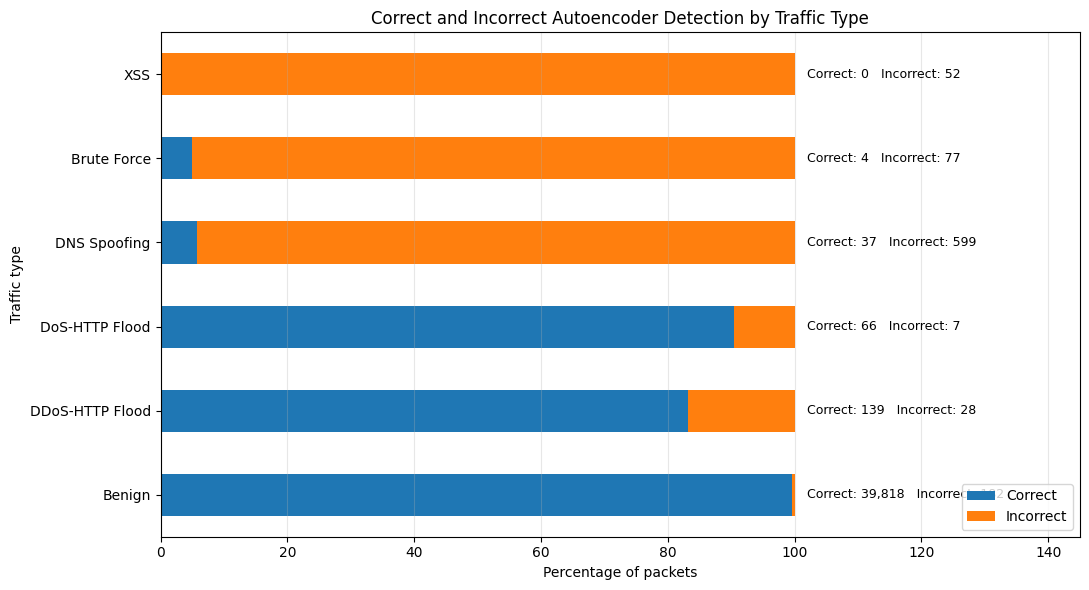

In [18]:
type_results = df_test_result[[ATTACK_COL]].copy()
type_results["y_true"] = y_test
type_results["y_pred"] = test_pred
type_results["correct"] = type_results["y_true"] == type_results["y_pred"]

result_by_type = type_results.groupby(ATTACK_COL).agg(total=("correct", "size"), correct=("correct", "sum"))
result_by_type["incorrect"] = result_by_type["total"] - result_by_type["correct"]
result_by_type["correct_rate"] = result_by_type["correct"] / result_by_type["total"] * 100
result_by_type["incorrect_rate"] = 100 - result_by_type["correct_rate"]

type_order = ["Benign", "DDoS-HTTP Flood", "DoS-HTTP Flood", "DNS Spoofing", "Brute Force", "XSS"]
result_by_type = result_by_type.reindex(type_order).dropna()

print("Classification results by traffic type:")
display(result_by_type[["total", "correct", "incorrect", "correct_rate"]].round(2))

plot_data = result_by_type[["correct_rate", "incorrect_rate"]]
ax = plot_data.plot(kind="barh", stacked=True, figsize=(11, 6))

for i, (_, row) in enumerate(result_by_type.iterrows()):
    count_text = f'Correct: {int(row["correct"]):,}   Incorrect: {int(row["incorrect"]):,}'
    ax.text(102, i, count_text, va="center", fontsize=9)

ax.set_xlim(0, 145)
ax.set_xlabel("Percentage of packets")
ax.set_ylabel("Traffic type")
ax.set_title("Correct and Incorrect Autoencoder Detection by Traffic Type")
ax.legend(["Correct", "Incorrect"], loc="lower right")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Reconstruction-score distribution by traffic type

This table and box plot show whether each attack type receives larger anomaly scores than benign traffic. A low or strongly overlapping distribution explains why an attack is frequently missed at the selected threshold.

Reconstruction scores by traffic type:


,count,mean,median,q75,q90
attack_type,,,,,
Benign,40000,0.4924,0.4874,0.7159,0.8510
DDoS-HTTP Flood,167,0.9709,0.9910,0.9949,0.9972
DoS-HTTP Flood,73,0.9826,0.9968,0.9978,0.9992
DNS Spoofing,636,0.7570,0.8121,0.9251,0.9637
Brute Force,81,0.7212,0.7549,0.9304,0.9599
XSS,52,0.6637,0.6657,0.8275,0.8670


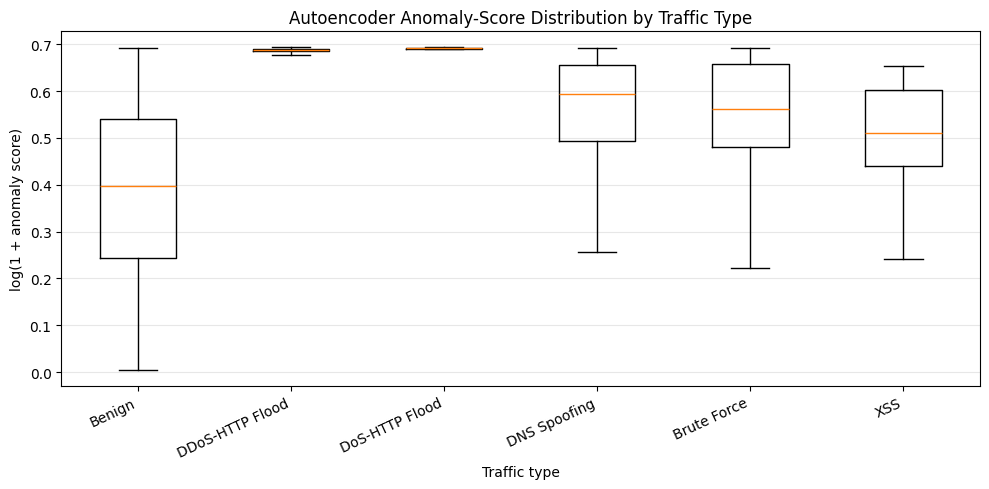

In [19]:
score_by_type = df_test_result.groupby(ATTACK_COL)["anomaly_score"].agg(
    count="size", mean="mean", median="median",
    q75=lambda x: x.quantile(0.75), q90=lambda x: x.quantile(0.90)
).reindex(type_order).dropna()

print("Reconstruction scores by traffic type:")
display(score_by_type.round(4))

box_data = [np.log1p(df_test_result.loc[df_test_result[ATTACK_COL] == traffic_type, "anomaly_score"]) for traffic_type in score_by_type.index]

plt.figure(figsize=(10, 5))
plt.boxplot(box_data, tick_labels=score_by_type.index, showfliers=False)
plt.xticks(rotation=25, ha="right")
plt.ylabel("log(1 + anomaly score)")
plt.xlabel("Traffic type")
plt.title("Autoencoder Anomaly-Score Distribution by Traffic Type")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### Confusion matrix visualization

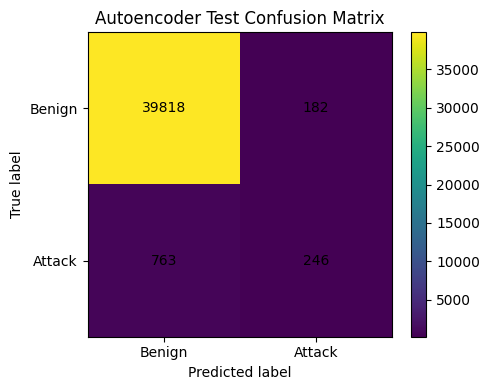

In [20]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.colorbar()
    plt.title(title)
    plt.xticks([0, 1], ["Benign", "Attack"])
    plt.yticks([0, 1], ["Benign", "Attack"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(y_test, test_pred, "Autoencoder Test Confusion Matrix")

#### ROC curve

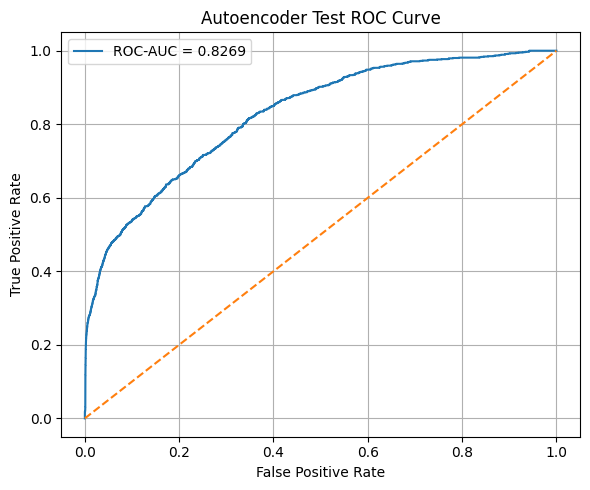

In [21]:
def plot_roc_curve(y_true, scores, title):
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc_value = roc_auc_score(y_true, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_roc_curve(y_test, test_scores, "Autoencoder Test ROC Curve")

#### Precision-recall curve

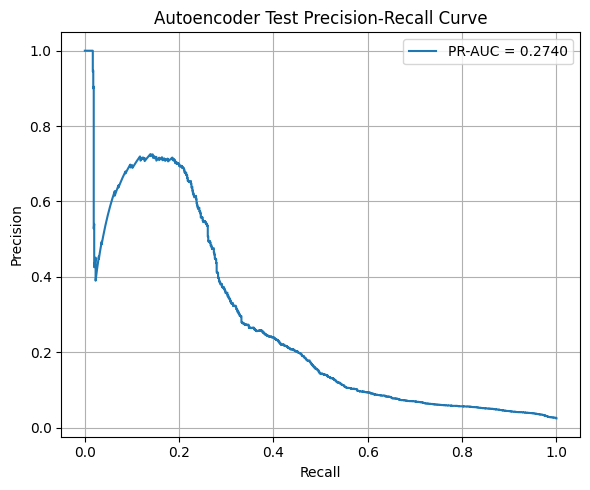

In [22]:
def plot_precision_recall_curve(y_true, scores, title):
    precision, recall, _ = precision_recall_curve(y_true, scores)
    pr_auc = average_precision_score(y_true, scores)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_precision_recall_curve(y_test, test_scores, "Autoencoder Test Precision-Recall Curve")

### Latent-space visualization

The encoder compresses each packet into its learned latent representation. PCA reduces those latent features to two dimensions so the true classes and generated alerts can be compared using the same plot structure as the other Phase 2 notebooks.

Explained variance: 0.5570052


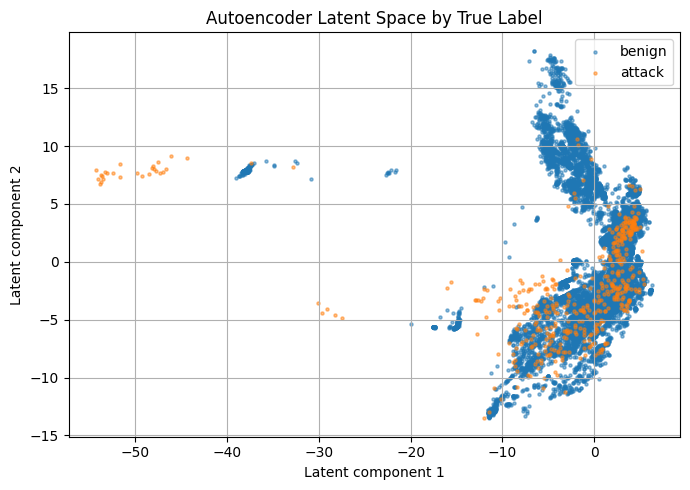

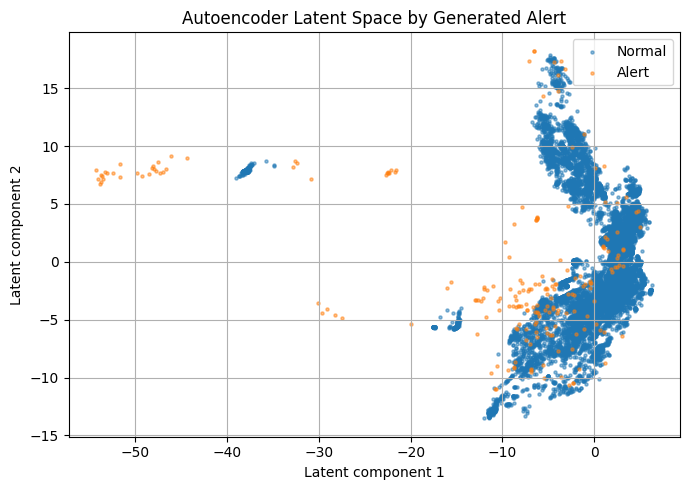

In [23]:
@torch.no_grad()
def encode_packets(model, X, batch_size=4096):
    model.eval()
    encoded = []

    for (batch,) in make_loader(X, batch_size):
        encoded.append(model.encoder(batch.to(DEVICE)).cpu().numpy())

    return np.concatenate(encoded)


plot_size = min(20000, X_test.shape[0])
rng = np.random.default_rng(1)
plot_idx = rng.choice(X_test.shape[0], size=plot_size, replace=False)
latent_test = encode_packets(autoencoder, X_test)[plot_idx]

if latent_test.shape[1] > 2:
    pca = PCA(n_components=2, random_state=1)
    latent_2d = pca.fit_transform(latent_test)
    print("Explained variance:", pca.explained_variance_ratio_.sum())
else:
    latent_2d = latent_test
    print("The bottleneck already has two dimensions.")

plot_df = pd.DataFrame({
    "Latent 1": latent_2d[:, 0],
    "Latent 2": latent_2d[:, 1],
    "binary_label": df_test_result.iloc[plot_idx][BINARY_COL].to_numpy(),
    "y_pred": df_test_result.iloc[plot_idx]["y_pred"].to_numpy(),
    "attack_type": df_test_result.iloc[plot_idx][ATTACK_COL].to_numpy()
})

plt.figure(figsize=(7, 5))
for label in ["benign", "attack"]:
    temp = plot_df[plot_df["binary_label"] == label]
    plt.scatter(temp["Latent 1"], temp["Latent 2"], s=5, alpha=0.5, label=label)
plt.xlabel("Latent component 1")
plt.ylabel("Latent component 2")
plt.title("Autoencoder Latent Space by True Label")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
for label in [0, 1]:
    temp = plot_df[plot_df["y_pred"] == label]
    name = "Normal" if label == 0 else "Alert"
    plt.scatter(temp["Latent 1"], temp["Latent 2"], s=5, alpha=0.5, label=name)
plt.xlabel("Latent component 1")
plt.ylabel("Latent component 2")
plt.title("Autoencoder Latent Space by Generated Alert")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Final Results

In [24]:
test_row = metrics_df.iloc[0]

print("Final Autoencoder test results")
print("------------------------------")
print(f"Bottleneck: {BEST_BOTTLENECK}")
print(f"Model variant: {BEST_MODEL_VARIANT}")
print(f"Score mode: {FINAL_SCORE_MODE}")
print(f"Latent clusters: {'Not used' if BEST_CLUSTER_K == 0 else BEST_CLUSTER_K}")
print(f"Reconstruction weight: {BEST_RECONSTRUCTION_WEIGHT:.2f}")
print(f"Precision: {test_row['precision']:.4f}")
print(f"Recall: {test_row['recall']:.4f}")
print(f"F1-score: {test_row['f1']:.4f}")
print(f"ROC-AUC: {test_row['roc_auc']:.4f}")
print(f"PR-AUC: {test_row['pr_auc']:.4f}")
print(f"FPR: {test_row['fpr']:.4f}")
print(f"FNR: {test_row['fnr']:.4f}")
print(f"Test alerts: {int(test_row['alerts'])}")

print("\nDetection rate by attack type")
for attack_type in type_order[1:]:
    row = result_by_type.loc[attack_type]
    print(f"{attack_type}: {row['correct_rate']:.2f}%")


Final Autoencoder test results
------------------------------
Bottleneck: 10
Model variant: Base
Score mode: Calibrated mean + latent K-means
Latent clusters: 25
Reconstruction weight: 0.75
Precision: 0.5748
Recall: 0.2438
F1-score: 0.3424
ROC-AUC: 0.8269
PR-AUC: 0.2740
FPR: 0.0046
FNR: 0.7562
Test alerts: 428

Detection rate by attack type
DDoS-HTTP Flood: 83.23%
DoS-HTTP Flood: 90.41%
DNS Spoofing: 5.82%
Brute Force: 4.94%
XSS: 0.00%


### Analysis

The autoencoder is trained without packet labels. The bottleneck is smaller than the preceding hidden layer, so the encoder must compress packet behavior rather than expand it. Bottleneck size is selected using validation PR-AUC after training.

The `top_k` column shows **All features** when the mean reconstruction error is used. In that case there is no numeric value for `k`, so the internal table stores a missing value only as a placeholder. It does not mean that tuning failed.

The expanded packet features add generic DNS, HTTP, service-port, protocol-layer and URI-shape information. These features do not encode the attack label, but they give the autoencoder more information about application-layer behavior that may help with DNS Spoofing, Brute Force and XSS.

The robust refinement step trains a second model after removing the highest-scoring 5% of training packets. The same unsupervised filtering is applied to the validation features used for early stopping. Feature-error calibration for the refined model is fitted only on the retained training subset, rather than on the packets that were deliberately removed.

Reconstruction error and latent-cluster distance capture different forms of abnormal behavior. Reconstruction error identifies packets the decoder cannot reproduce, while latent K-means identifies packets that are far from common encoded traffic patterns. Labels are not used to fit the autoencoder or K-means. Validation PR-AUC determines whether the latent score improves the reconstruction-only baseline and selects their weight.

The alert threshold is selected using validation data only. Candidate alert rates are compared by F1-score while keeping validation false-positive rate at or below 1.5%. The frozen threshold is then applied to the test set without recalculation.

The traffic-type table shows which attacks have distinctive packet-level behavior. DDoS and DoS packets usually produce stronger packet-level deviations. XSS and Brute Force can resemble benign packets at the packet level, so flow-level supervised refinement in Phase 3 may still be necessary even after these improvements.
